# ARASAAC vs HF vs Eval Dataset Analysis

The objective of this notebook is to analyze the mismatch between the source datasets and the evaluation dataset, in order to adjust both of them to allow a fair evalutaion of the agent. 

In practice this notebook will produce a merged source dataset `en_eval` and a filtered evaluation dataset `eval_filtered`, which will be used in the next steps of the project.

## 1. Imports and Setup

In [1]:
import os, json, ast
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from datasets import load_dataset
from dotenv import load_dotenv
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent  

ANNOTATION_DIR = PROJECT_ROOT / "annotation"
EN_DIR         = PROJECT_ROOT / "app" / "datasets" / "en"
EN_EVAL_DIR    = PROJECT_ROOT / "app" / "datasets" / "en_eval"
EVAL_FILTERED  = ANNOTATION_DIR / "eval_filtered.parquet"

HF_REPO_PICTOGRAMS = "disi-unibo-nlp-students/ARASAAC-Pictograms"
HF_REPO_SENTENCES  = "disi-unibo-nlp-students/aac_database"

load_dotenv(PROJECT_ROOT / "app" / ".env")
HF_TOKEN = os.environ.get("HF_TOKEN", True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}  (exists={PROJECT_ROOT.exists()})")
print(f"EN_DIR       : {EN_DIR}  (exists={EN_DIR.exists()})")
print(f"EN_EVAL_DIR  : {EN_EVAL_DIR}  (exists={EN_EVAL_DIR.exists()})")

/Users/pelle/python_venvs/BDATM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT : /Users/pelle/Development/GitHub/aac-mcp-agent  (exists=True)
EN_DIR       : /Users/pelle/Development/GitHub/aac-mcp-agent/app/datasets/en  (exists=True)
EN_EVAL_DIR  : /Users/pelle/Development/GitHub/aac-mcp-agent/app/datasets/en_eval  (exists=False)


## 2. Load datasest

### 2.1 Load local copy of the official ARASAAC dataset

In [2]:
# SRC_LOCAL
with open(EN_DIR / "pictograms.json", encoding="utf-8") as f:
    local_pics = json.load(f)
df_local = pd.DataFrame.from_dict(local_pics, orient="index")
df_local.drop(["id"], axis=1, inplace=True)
df_local.index = df_local.index.astype(int)
df_local = df_local.reset_index().rename(columns={"index": "pictogram_id"})
df_local = df_local.sort_values("pictogram_id").reset_index(drop=True)

display(df_local)

,pictogram_id,keywords,categories,synsets,tags,sex,violence,schematic,aac,aac_color,skin,hair,created,last_updated
0,2239,"[{'type': 2, 'keyword': 'bee', 'plural': 'bees...","[herbivorous, insect, oviparous, flying animal...",[02209508-n],"[animal, herbivorous, invertebrate, arthropod,...",False,False,False,False,False,False,False,2007-12-11T21:59:56.000Z,2020-12-27T11:59:40.369Z
1,2242,"[{'type': 2, 'keyword': 'coat', 'plural': 'coa...","[clothes, core vocabulary-object, fashion]","[03061006-n, 03461607-n, 04195013-n]","[object, fashion, clothes, core vocabulary]",False,False,False,True,True,False,False,2007-12-12T09:33:40.000Z,2024-12-09T06:11:43.097Z
2,2243,"[{'type': 2, 'keyword': 'grandmother', 'plural...","[elderly, family]",[10162267-n],"[person, elderly, family]",False,False,False,False,False,True,True,2007-12-12T09:56:39.000Z,2022-06-14T17:58:08.293Z
3,2244,"[{'type': 2, 'keyword': 'grandfather', 'plural...","[elderly, family]",[10161911-n],"[person, elderly, family]",False,False,False,False,False,True,True,2007-12-12T09:57:36.000Z,2020-11-26T10:23:32.187Z
4,2245,"[{'type': 4, 'keyword': 'boring', 'plural': No...","[qualifying adjective, feeling]",[01348155-s],"[communication, language, adjective, qualifyin...",False,False,False,False,False,True,False,2007-12-12T09:58:31.000Z,2020-11-22T15:44:11.932Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13775,39853,"[{'type': 3, 'keyword': 'put nursery robe on',...","[verb, clothes, students]",[00050369-v],"[communication, language, verb, object, fashio...",False,False,False,False,False,True,True,2026-04-12T10:21:07.958Z,2026-04-13T08:58:06.530Z
13776,39854,"[{'type': 2, 'keyword': 'amphitheater', 'plura...","[cultural building, monument]",[],"[place, building, culture, monument]",False,False,False,False,False,False,True,2026-04-12T10:21:07.958Z,2026-04-13T08:54:07.390Z
13777,39855,"[{'type': 4, 'keyword': 'many months ago', 'pl...",[adverb of time],[],"[communication, language, adverb, adverb of time]",False,False,False,False,False,False,False,2026-04-13T10:31:28.953Z,2026-04-13T11:33:37.188Z
13778,39856,"[{'type': 4, 'keyword': 'relieved', 'plural': ...","[verb, human response]",[],"[communication, language, verb, psychology, hu...",False,False,True,False,False,True,False,2026-04-13T10:31:28.953Z,2026-04-13T11:45:28.104Z


### 2.2 Load the huggingface version of the previous dataset, provided by the university.

In [3]:
# SRC_HF
df_hf = load_dataset(HF_REPO_PICTOGRAMS, split="train", token=HF_TOKEN)              
df_hf = df_hf.to_pandas()     
df_hf = df_hf.sort_values("pictogram_id").reset_index(drop=True)
display(df_hf)

,image,pictogram_id,tags,categories,keywords
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2239,"[animal, herbivorous, invertebrate, arthropod,...","[herbivorous, insect, oviparous, flying animal...","[{'hasLocution': True, 'keyword': 'bee', 'mean..."
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2242,"[object, fashion, clothes, core vocabulary]","[clothes, core vocabulary-object]","[{'hasLocution': True, 'keyword': 'coat', 'mea..."
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2243,"[person, elderly, family]","[elderly, family]","[{'hasLocution': True, 'keyword': 'grandmother..."
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2244,"[person, elderly, family]","[elderly, family]","[{'hasLocution': True, 'keyword': 'grandfather..."
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2245,"[communication, language, adjective, qualifyin...","[qualifying adjective, feeling]","[{'hasLocution': True, 'keyword': 'boring', 'm..."
...,...,...,...,...,...
12469,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38548,"[communication, language, verb, leisure, sport...","[verb, sport modality]","[{'hasLocution': False, 'keyword': 'golf', 'me..."
12470,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38549,"[communication, language, verb, leisure, sport...","[verb, traditional game]","[{'hasLocution': False, 'keyword': 'play petan..."
12471,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38550,"[communication, language, verb, usual verbs, p...","[usual verbs, basic needs, routine]","[{'hasLocution': False, 'keyword': 'sleep in t..."
12472,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38552,"[health, medicine, medical equipment, nursing ...","[nursing equipment, orthopedic product]","[{'hasLocution': False, 'keyword': 'anti-bedso..."


### 2.3 Load the evaluation dataset, provided by the university.

In [4]:
# EVAL
df_eval = load_dataset(
    "disi-unibo-nlp-students/aac_database",
    data_files="data/sentences/*", 
    split="train",
    token=HF_TOKEN,
).to_pandas()
display(df_eval)

,sentence,concepts
0,The blue train is going fast.,[{'candidates': [{'description': 'Passenger tr...
1,I see the big yellow bus.,"[{'candidates': [{'description': ""The word is ..."
2,The music is too loud in here.,"[{'candidates': [{'description': ""The word is ..."
3,Look at the bubbles popping.,"[{'candidates': [{'description': ""The word is ..."
4,My shirt feels scratchy on my neck.,[{'candidates': [{'description': 'person weari...
...,...,...
2456,Do you have a dog at your house?,"[{'candidates': [{'description': ""The word is ..."
2457,I am really good at building robots.,"[{'candidates': [{'description': ""The word is ..."
2458,We went to the zoo to see lions.,"[{'candidates': [{'description': 'A lion, a la..."
2459,I want to play cars with you.,"[{'candidates': [{'description': ""The word is ..."


In [5]:
df_eval.iloc[0, 1]

array([{'candidates': array([{'description': 'Passenger train composed of a locomotive and a carriage for transporting travelers on rails', 'id': '2603', 'keywords': 'train, passenger train'},
              {'description': 'A steam-powered train with a passenger carriage, designed for public transportation.', 'id': '29010', 'keywords': ''},
              {'description': 'Passenger train composed of multiple connected carriages for transporting travelers on tracks', 'id': '7282', 'keywords': 'train, passenger train'},
              {'description': 'Train movement along rail track with marked paths indicating direction or route selection.', 'id': '10187', 'keywords': 'travel, cover, train, rail'},
              {'description': 'Railway conductor standing beside high-speed train on tracks, representing transportation service role', 'id': '36763', 'keywords': 'engine driver, engineer, locomotive engineer'},
              {'description': 'railway station where trains arrive and depart for p

Most of those parts are not very useful for us. We actually need a mapping to ids to check the proposed ids.

It must be noted that many samples seems meaningless as descriptions and so the ids could follow.

In [6]:
records = []
for sentence_id, row in df_eval.iterrows():
    sentence = row["sentence"]
    concepts = []
    for concept in row["concepts"]:
        concepts.append({
            "concept_text"  : concept["text"],
            "gold_id"       : int(concept["pictogram"]["id"]),
            "candidate_ids" : [int(c["id"]) for c in concept["candidates"]],
        })
    records.append({
        # "sentence_id" : sentence_id,
        "sentence"    : sentence,
        "concepts"    : concepts,
    })

df_eval = pd.DataFrame(records)
print(json.dumps(df_eval.iloc[0]["concepts"], indent=2))

[
  {
    "concept_text": "The blue train",
    "gold_id": 7282,
    "candidate_ids": [
      2603,
      29010,
      7282,
      10187,
      36763,
      6494,
      29008,
      2472,
      27768,
      27769
    ]
  },
  {
    "concept_text": "go",
    "gold_id": 8544,
    "candidate_ids": [
      9851,
      8544,
      5946,
      17054,
      6955,
      8643,
      27769,
      27768,
      5306,
      25133
    ]
  },
  {
    "concept_text": "fast",
    "gold_id": 5306,
    "candidate_ids": [
      8544,
      5306,
      9851,
      36600,
      17054,
      5946,
      38219,
      8643,
      36763,
      38224
    ]
  }
]


## 3. Dataset quality evaluation and cleaning

In [7]:
import re
from collections import Counter

_SYNSET_RE = re.compile(r"^\d{8}-[nvarbs]$")
_TYPE_LABELS = {1: "proper noun", 2: "common noun", 3: "verb", 4: "adjective", 5: "social", 6: "misc"}

def df_quality_check(df: pd.DataFrame, mode: str) -> dict:
    """
    General quality check over a pictogram dataset.

    1. Duplicate ids
    2. None in key columns (distribution 0→n_cols)
    3. Empty list-columns (distribution 0→n_cols)
    4. Keyword malformations (type field, keyword string, meaning field)
    5. List-column malformations (non-str items, empty-str items, synset format)

    mode: "local" | "hf"
    """

    ID_COL    = "pictogram_id"
    LIST_COLS = ["keywords", "categories", "tags"]
    if "synsets" in df.columns: LIST_COLS.append("synsets")
    KEY_COLS  = [ID_COL] + LIST_COLS

    results = {}

    # 1) Duplicate ids
    dup_mask = df[ID_COL].duplicated(keep=False)
    results["duplicate_ids"] = {
        "count": int(dup_mask.sum()),
        "ids":   df.loc[dup_mask, ID_COL].tolist(),
    }

    # 2) None in key cols
    none_masks = {c: df[c].isna() for c in KEY_COLS}
    none_per_row = sum(m.astype(int) for m in none_masks.values())
    results["none_cols"] = {
        "per_col":     {c: int(none_masks[c].sum()) for c in KEY_COLS},
        "distribution": none_per_row.value_counts().sort_index().to_dict(),
    }

    # 3) Empty list-cols
    empty_masks = {c: df[c].apply(lambda x: isinstance(x, list) and len(x) == 0) for c in LIST_COLS}
    empty_per_row = sum(m.astype(int) for m in empty_masks.values())
    results["empty_cols"] = {
        "per_col":      {c: int(empty_masks[c].sum()) for c in LIST_COLS},
        "distribution": empty_per_row.value_counts().sort_index().to_dict(),
    }

    # 4) Keyword malformations
    kw = {
        "n_entries_total":         0,
        "n_entries_bad":           0,
        "type_missing_or_non_int": 0,
        "type_distribution":       Counter(),
        "kw_empty_or_whitespace":  0,
        "meaning_none":            0,
        "meaning_empty_str":       0,
        "meaning_key_absent":      0,
        "intra_pic_duplicate_kws": 0,
    }
    for kws in df["keywords"].dropna():
        if not isinstance(kws, list) or len(kws) == 0:
            continue
        kw_texts, pic_bad = [], False
        for entry in kws:
            if not isinstance(entry, dict):
                kw["n_entries_bad"] += 1; pic_bad = True; continue
            kw["n_entries_total"] += 1
            entry_bad = False
            if mode == "local":
                t = entry.get("type")
                if not isinstance(t, (int, float)):
                    kw["type_missing_or_non_int"] += 1; entry_bad = True
                else:
                    kw["type_distribution"][int(t)] += 1
            kw_str = entry.get("keyword")
            if not isinstance(kw_str, str) or kw_str.strip() == "":
                kw["kw_empty_or_whitespace"] += 1; entry_bad = True
            else:
                kw_texts.append(kw_str.lower().strip())
            if "meaning" not in entry:
                kw["meaning_key_absent"] += 1; entry_bad = True
            else:
                m = entry["meaning"]
                if m is None:                               
                    kw["meaning_none"] += 1
                elif isinstance(m, str) and m.strip() == "": 
                    kw["meaning_empty_str"] += 1
            if entry_bad:
                kw["n_entries_bad"] += 1; pic_bad = True
        if len(kw_texts) != len(set(kw_texts)):
            kw["intra_pic_duplicate_kws"] += 1
    kw["type_distribution"] = dict(sorted(kw["type_distribution"].items()))
    results["keyword_issues"] = kw

    # 5) List-col malformations (categories, tags, synsets)
    list_mal = {}
    for col in LIST_COLS:
        if col == "keywords": continue
        n_non_str, n_empty_str, n_bad_synset = 0, 0, 0
        for lst in df[col].dropna():
            if not isinstance(lst, list): continue
            for item in lst:
                if not isinstance(item, str):      
                    n_non_str += 1
                elif item.strip() == "":           
                    n_empty_str += 1
                elif col == "synsets" and not _SYNSET_RE.match(item):
                    n_bad_synset += 1
        entry = {"n_items_non_str": n_non_str, "n_items_empty_str": n_empty_str}
        if col == "synsets": 
            entry["n_items_bad_synset_fmt"] = n_bad_synset
        list_mal[col] = entry
    results["list_malformations"] = list_mal

    return results

### 3.1 `df_local` dataset

In [8]:
quality_local = df_quality_check(df_local, mode="local")

s = json.dumps(quality_local, indent=2, default=str)
s = re.sub(r'\n  "', '\n\n  "', s) # principal keys separated
print(s)

{

  "duplicate_ids": {
    "count": 0,
    "ids": []
  },

  "none_cols": {
    "per_col": {
      "pictogram_id": 0,
      "keywords": 0,
      "categories": 0,
      "tags": 0,
      "synsets": 0
    },
    "distribution": {
      "0": 13780
    }
  },

  "empty_cols": {
    "per_col": {
      "keywords": 0,
      "categories": 35,
      "tags": 100,
      "synsets": 1213
    },
    "distribution": {
      "0": 12473,
      "1": 1269,
      "2": 35,
      "3": 3
    }
  },

  "keyword_issues": {
    "n_entries_total": 26470,
    "n_entries_bad": 0,
    "type_missing_or_non_int": 0,
    "type_distribution": {
      "1": 924,
      "2": 16358,
      "3": 6130,
      "4": 1959,
      "5": 397,
      "6": 702
    },
    "kw_empty_or_whitespace": 0,
    "meaning_none": 17461,
    "meaning_empty_str": 0,
    "meaning_key_absent": 0,
    "intra_pic_duplicate_kws": 138
  },

  "list_malformations": {
    "categories": {
      "n_items_non_str": 0,
      "n_items_empty_str": 0
    },
    "ta

For what concerns the quality of the dataset structure there are no duplicated ids or none rows. The empty columns are concentrated in `synsets` and there are few exceptions we can ignore.

For what concerns the keywords, we can see that most of them do not have a meaning and 138 times we have keywords with the same keyword name in the same pictogram.

The other elements do not show problems.

### 3.2 `df_hf` dataset

In [9]:
quality_hf = df_quality_check(df_hf, mode="hf")

s = json.dumps(quality_hf, indent=2, default=str)
s = re.sub(r'\n  "', '\n\n  "', s) # principal keys separated
print(s)

{

  "duplicate_ids": {
    "count": 20,
    "ids": [
      38264,
      38264,
      38265,
      38265,
      38266,
      38266,
      38267,
      38267,
      38268,
      38268,
      38269,
      38269,
      38270,
      38270,
      38271,
      38271,
      38272,
      38272,
      38273,
      38273
    ]
  },

  "none_cols": {
    "per_col": {
      "pictogram_id": 0,
      "keywords": 1817,
      "categories": 1817,
      "tags": 1817
    },
    "distribution": {
      "0": 10657,
      "3": 1817
    }
  },

  "empty_cols": {
    "per_col": {
      "keywords": 0,
      "categories": 0,
      "tags": 0
    },
    "distribution": {
      "0": 12474
    }
  },

  "keyword_issues": {
    "n_entries_total": 0,
    "n_entries_bad": 0,
    "type_missing_or_non_int": 0,
    "type_distribution": {},
    "kw_empty_or_whitespace": 0,
    "meaning_none": 0,
    "meaning_empty_str": 0,
    "meaning_key_absent": 0,
    "intra_pic_duplicate_kws": 0
  },

  "list_malformations": {
    "c

Here we have more structural problems:
1. We have 20 duplicated ids, which are 10 uniques duplicated twice. They cannot coexist in the same dataset and have to be removed.
2. We have 1817 rows with all the columns none, while none of them are empty. If they exist in the local dataset we can put local values there.

Other structures are ok.

In [10]:
# See what are the duplicated ids
dup_ids = set(quality_hf["duplicate_ids"]["ids"])
df_hf[df_hf["pictogram_id"].isin(dup_ids)]

,image,pictogram_id,tags,categories,keywords
12177,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38264,None,None,None
12178,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38264,"[person, group, health, medicine, professional...","[group, health personnel, sanitary professiona...","[{'hasLocution': False, 'keyword': 'nurses ass..."
12179,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38265,None,None,None
12180,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38265,"[communication, language, verb, object, fashio...","[verb, accessories, routine, teaching activity]","[{'hasLocution': False, 'keyword': 'put on bac..."
12181,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38266,"[communication, language, verb, psychology, di...","[verb, disruptive behavior]","[{'hasLocution': False, 'keyword': 'mischief',..."
12182,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38266,None,None,None
12183,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38267,"[feeding, food, processed food, cold meat]",[cold meat],"[{'hasLocution': False, 'keyword': 'morcón', '..."
12184,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38267,None,None,None
12185,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38268,None,None,None
12186,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38268,"[plant, plant physiology]",[plant physiology],"[{'hasLocution': False, 'keyword': 'gall', 'me..."


In [11]:
# Remove the None duplicated rows
df_hf = df_hf[~(df_hf["pictogram_id"].isin(dup_ids) & df_hf["tags"].isna())].reset_index(drop=True)

In [12]:
none_ids = set(df_hf[df_hf["keywords"].isna()]["pictogram_id"])
local_ids = set(df_local["pictogram_id"])
in_local = none_ids & local_ids


print(f"Local has {len(in_local)}/{len(none_ids)} ids, the others are irrecoverable.")

Local has 1/1807 ids, the others are irrecoverable.


This means that with our agent, those id are lost and it can't retrive them. This is for sure a problem but maybe it can be not influential for evaluation if those ids are not in the evaluation dataset. 

Otherwise we have to consider the idea to:
1. remove them from the dataset
2. use another retrieval strategy

In [13]:
def contamination(row):
    n = len(row["concepts"])
    gold_none = sum(1 for c in row["concepts"] if c["gold_id"] in none_ids)
    cand_fracs = [
        sum(1 for cid in c["candidate_ids"] if cid in none_ids) / len(c["candidate_ids"])
        for c in row["concepts"]
        if c["gold_id"] not in none_ids
    ]
    return pd.Series({
        "n_concepts"                      : n,
        "gold_ids_with_no_metadata"       : gold_none,
        "gold_no_metadata_frac"           : gold_none / n,
        "max_cand_no_metadata_frac"       : max(cand_fracs)                    if cand_fracs else None,
        "mean_cand_no_metadata_frac"      : sum(cand_fracs) / len(cand_fracs)  if cand_fracs else None,
        "n_concepts_with_cand_above_20pct": sum(1 for f in cand_fracs if f > 0.2),
    })

contam = df_eval.apply(contamination, axis=1)
clean  = contam[contam["gold_ids_with_no_metadata"] == 0]

# (1) sentences by number of concepts whose gold has no metadata
print("(1) Sentences grouped by how many of their concepts have an irrecoverable gold id")
print(contam["gold_ids_with_no_metadata"].value_counts().sort_index().to_frame("n_sentences"))

print()
print()

# (2) among clean sentences, distribution of candidate contamination
print("(2) Among the clean sentences (gold ok), fraction of candidates per concept that are irrecoverable")
print(clean[["max_cand_no_metadata_frac", "mean_cand_no_metadata_frac"]].describe().round(3))

print()
print()

# (3) among clean sentences, how many concepts per sentence exceed the 20% candidate threshold
print("(3) Among clean sentences, how many concepts per sentence have >20% irrecoverable candidates")
print(clean["n_concepts_with_cand_above_20pct"].value_counts().sort_index().to_frame("n_sentences"))

(1) Sentences grouped by how many of their concepts have an irrecoverable gold id
                           n_sentences
gold_ids_with_no_metadata             
0.0                               2025
1.0                                403
2.0                                 33


(2) Among the clean sentences (gold ok), fraction of candidates per concept that are irrecoverable
       max_cand_no_metadata_frac  mean_cand_no_metadata_frac
count                   2025.000                     2025.00
mean                       0.124                        0.06
std                        0.100                        0.06
min                        0.000                        0.00
25%                        0.000                        0.00
50%                        0.100                        0.05
75%                        0.200                        0.10
max                        0.500                        0.28


(3) Among clean sentences, how many concepts per sentence have >20% irr

The proposed filtering strategy is:
1. Remove sentences with at least one concept whose gold id has no metadata, ensuring every gold pictogram is reachable by the agent.
2. Remove sentences where at least one concept has more than 20% of candidate ids without metadata, ensuring the candidate pool is not artificially reduced beyond an acceptable threshold.

### 3.3 `df_eval` dataset

In [14]:
df_eval_filtered = df_eval[
    (contam["gold_ids_with_no_metadata"] == 0) &
    (contam["n_concepts_with_cand_above_20pct"] == 0)
].reset_index(drop=True)

print(f"Total sentences          : {len(df_eval)}")
print(f"Dropped (gold filter)    : {(contam['gold_ids_with_no_metadata'] > 0).sum()}")
print(f"Dropped (cand filter)    : {(contam['n_concepts_with_cand_above_20pct'] > 0).sum()}")
print(f"df_eval_filtered         : {len(df_eval_filtered)}")

df_eval_filtered

Total sentences          : 2461
Dropped (gold filter)    : 436
Dropped (cand filter)    : 305
df_eval_filtered         : 1787


,sentence,concepts
0,The blue train is going fast.,"[{'concept_text': 'The blue train', 'gold_id':..."
1,The music is too loud in here.,"[{'concept_text': 'The music', 'gold_id': 3748..."
2,Look at the bubbles popping.,"[{'concept_text': 'look', 'gold_id': 37369, 'c..."
3,My shirt feels scratchy on my neck.,"[{'concept_text': 'My shirt', 'gold_id': 2309,..."
4,The fan is spinning round and round.,"[{'concept_text': 'The fan', 'gold_id': 2612, ..."
...,...,...
1782,I want to be a pilot when I grow up.,"[{'concept_text': 'I', 'gold_id': 8128, 'candi..."
1783,Do you have a dog at your house?,"[{'concept_text': 'you', 'gold_id': 36081, 'ca..."
1784,I am really good at building robots.,"[{'concept_text': 'I', 'gold_id': 9851, 'candi..."
1785,We went to the zoo to see lions.,"[{'concept_text': 'We', 'gold_id': 8693, 'cand..."


In [15]:
# 1) Duplicate sentences
dup_mask = df_eval_filtered["sentence"].duplicated(keep=False)
print(f"Duplicate sentences: {dup_mask.sum()}")
if dup_mask.sum() > 0:
    dup_counts = df_eval_filtered[dup_mask]["sentence"].value_counts().rename("count")
    dist = dup_counts.value_counts().sort_index()
    print("Distribution of duplicates:")
    for n_times, n_sentences in dist.items():
        print(f"\t- {n_sentences} sentence appear exactly {n_times} times")
    display(dup_counts.to_frame())

print()

# 2) Concepts — total and top-N most frequent concept_text
N = 100
all_concepts = [c["concept_text"] for _, r in df_eval_filtered.iterrows() for c in r["concepts"]]
print(f"Total concepts: {len(all_concepts)}")
print(f"Unique concept_text: {len(set(all_concepts))}")
top = pd.Series(all_concepts).value_counts().head(N)
middle = int(N/2)
left, right = top.iloc[:middle], top.iloc[middle:]
print(f"\nTop {N} most frequent concept_text:")
for (c1, n1), (c2, n2) in zip(left.items(), right.items()):
    print(f"\t{c1:<30} {n1:>4}    {c2:<30} {n2:>4}")

print()

# 3) Concepts per sentence — mean + std
concepts_per_sentence = pd.Series([len(r["concepts"]) for _, r in df_eval_filtered.iterrows()])
print(f"Concepts per sentence: mean={concepts_per_sentence.mean():.2f}  std={concepts_per_sentence.std():.2f}  min={concepts_per_sentence.min()}  max={concepts_per_sentence.max()}")

print()

# 4) Candidates per concept — mean + std
cand_lengths = pd.Series([len(c["candidate_ids"]) for _, r in df_eval_filtered.iterrows() for c in r["concepts"]])
print(f"Candidates per concept: mean={cand_lengths.mean():.2f}  std={cand_lengths.std():.2f}  min={cand_lengths.min()}  max={cand_lengths.max()}")

print()

# 5) Gold in candidates
gold_in_cands = sum(
    c["gold_id"] in c["candidate_ids"]
    for _, r in df_eval_filtered.iterrows()
    for c in r["concepts"]
)
print(f"Gold in candidates: {gold_in_cands} / {len(all_concepts)} ({gold_in_cands/len(all_concepts):.1%})")

Duplicate sentences: 80
Distribution of duplicates:
	- 27 sentence appear exactly 2 times
	- 5 sentence appear exactly 3 times
	- 1 sentence appear exactly 5 times
	- 1 sentence appear exactly 6 times


,count
sentence,
I need a tissue for my nose.,6
I need to go to the bathroom.,5
I need a break in the quiet corner.,3
I need to use the bathroom right now.,3
I need a drink of water.,3
Can I have a hug?,3
I need to sit down for a minute.,3
My shirt feels scratchy on my neck.,2
The slide is too hot for my legs.,2



Total concepts: 6571
Unique concept_text: 1997

Top 100 most frequent concept_text:
	I                               911    tight                            14
	me                              191    listen                           14
	feel                            183    start                            14
	need                            168    fast                             13
	want                            160    cold                             13
	you                             132    say                              13
	we                               86    happy                            13
	like                             70    dry                              13
	look                             66    You                              13
	it                               62    myself                           13
	help                             53    this                             13
	sit                              50    good                             12
	pl

Ok so we can see that there is a quite important duplication issue that has to be better investigated, maybe the same sentence has various meaninings in a realistic way, or maybe it is a generation problem.

In [18]:
from itertools import combinations

# Define the unique signature of a row, made to be comparable
def row_sig(row):
    return tuple(
        (c["concept_text"], c["gold_id"], tuple(sorted(c["candidate_ids"])))
        for c in sorted(row["concepts"], key=lambda c: c["concept_text"])
    )

exact, diff_concepts, diff_gold_only, diff_cands_only, diff_both = 0, 0, 0, 0, 0

dup_rows = df_eval_filtered[dup_mask]
dup_sentences = df_eval_filtered[dup_mask]["sentence"].unique()
for sent in dup_sentences:
    copies = dup_rows[dup_rows["sentence"] == sent]
    rows = [r for _, r in copies.iterrows()]
    for i, j in combinations(range(len(rows)), 2):
        a, b = row_sig(rows[i]), row_sig(rows[j])

        # first check if concept texts are the same
        same_texts = [x[0] for x in a] == [y[0] for y in b]
        if not same_texts:
            diff_concepts += 1
            continue

        # only if texts match, compare gold and candidates
        same_gold  = all(x[1] == y[1] for x, y in zip(a, b))
        same_cands = all(x[2] == y[2] for x, y in zip(a, b))

        if same_gold and same_cands:  exact           += 1
        elif same_gold:               diff_cands_only += 1
        elif same_cands:              diff_gold_only  += 1
        else:                         diff_both       += 1

print(f"Duplicate rows                              : {dup_mask.sum()}")
print(f"Duplicate sentence pairs analyzed           : {exact + diff_concepts + diff_gold_only + diff_cands_only + diff_both}")
print(f"\t- different concept texts               : {diff_concepts}")
print(f"\t- exact (same gold + same candidates)   : {exact}")
print(f"\t- same gold, different candidates       : {diff_cands_only}")
print(f"\t- same candidates, different gold       : {diff_gold_only}")
print(f"\t- different gold and candidates         : {diff_both}")

Duplicate rows                              : 80
Duplicate sentence pairs analyzed           : 67
	- different concept texts               : 0
	- exact (same gold + same candidates)   : 31
	- same gold, different candidates       : 0
	- same candidates, different gold       : 36
	- different gold and candidates         : 0


At this point the exact duplicates have to be removed, while the others may represent important meaning variations of the same sentence, so they can be kept but it is better to check also them.

In [19]:
exact_groups, ambiguous_groups = [], []

for sent, rows in [(sent, [r for _, r in dup_rows[dup_rows["sentence"] == sent].iterrows()])
                   for sent in dup_sentences]:
    sigs = [row_sig(r) for r in rows]
    unique_sigs = list(dict.fromkeys(sigs))  # preserva ordine, rimuove duplicati esatti

    if len(unique_sigs) == 1:
        # all copies are identical
        exact_groups.append((sent, rows))
    else:
        # keep only one representative per unique signature
        seen, unique_rows = set(), []
        for r, s in zip(rows, sigs):
            if s not in seen:
                seen.add(s)
                unique_rows.append(r)
        ambiguous_groups.append((sent, unique_rows))

print(f"=== EXACT DUPLICATES ({len(exact_groups)} groups) ===")
for sent, rows in exact_groups:
    print(f"\n  [{len(rows)}x] \"{sent}\"")
    for c in rows[0]["concepts"]:
        print(f"\t- {c['concept_text']:<35} gold={c['gold_id']}")

print(f"\n=== AMBIGUOUS DUPLICATES ({len(ambiguous_groups)} groups) ===")
for sent, rows in ambiguous_groups:
    print(f"\n  [{len(rows)} unique annotations] \"{sent}\"")
    for concept_idx in range(len(rows[0]["concepts"])):
        text  = rows[0]["concepts"][concept_idx]["concept_text"]
        golds = [r["concepts"][concept_idx]["gold_id"] for r in rows]
        if len(set(golds)) == 1:
            print(f"\t- {text:<35} gold={golds[0]} (same)")
        else:
            print(f"\t- {text:<35} gold={golds}  ← DIVERGES")

=== EXACT DUPLICATES (16 groups) ===

  [2x] "The slide is too hot for my legs."
	- The slide                           gold=36880
	- hot                                 gold=6952
	- my legs                             gold=2810

  [2x] "I do not like the loud school bell."
	- I                                   gold=9851
	- like                                gold=37825
	- the loud school bell                gold=5938

  [2x] "My backpack is in my cubby."
	- My backpack                         gold=2475
	- my cubby                            gold=36766

  [2x] "My tummy feels funny."
	- My tummy                            gold=3309
	- feel                                gold=7040
	- funny                               gold=10273

  [2x] "I am thirsty for some cold water."
	- I                                   gold=37207
	- thirsty                             gold=4963
	- some cold water                     gold=36023

  [3x] "I need a drink of water."
	- I                            

Ok also the ambiguous duplicates show a strange behaviour, for example in 

```
  [2 unique annotations] "My shirt feels scratchy on my neck."
	- My shirt                            gold=2309 (same)
	- feel                                gold=[37339, 7040]  ← DIVERGES
	- scratchy                            gold=[28762, 37339]  ← DIVERGES
	- my neck                             gold=2881 (same)
```

We can see that the "feel" id 37339 is found also for "scratchy" in the second duplicated annotation, meaning that it has "feel" twice with different ids (7040 and 37339). 

I think that this is problematic in evaluation and has to be handled.

In [20]:
from IPython.display import display, HTML
import io, base64

def show_pictograms(ids, size: int = 150):
    if isinstance(ids, int):
        ids = [ids]
    
    rows_html = "<table><tr><th>id</th><th>ARASAAC</th><th>df_hf</th></tr>"
    
    for pic_id in ids:
        arasaac_url = f"https://static.arasaac.org/pictograms/{pic_id}/{pic_id}_300.png"
        arasaac_cell = f"<img src='{arasaac_url}' width='{size}'/>"
        
        row = df_hf[df_hf["pictogram_id"] == pic_id]
        if row.empty:
            hf_cell = "<span style='color:red'>not found</span>"
        else:
            img_bytes = row.iloc[0]["image"]["bytes"]
            b64 = base64.b64encode(img_bytes).decode("utf-8")
            hf_cell = f"<img src='data:image/png;base64,{b64}' width='{size}'/>"
        
        rows_html += f"<tr><td><b>{pic_id}</b></td><td>{arasaac_cell}</td><td>{hf_cell}</td></tr>"
    
    rows_html += "</table>"
    display(HTML(rows_html))

[2/18] "I want to wear my noise-canceling headphones."

'I' — same gold=37857


id,ARASAAC,df_hf
37857,,

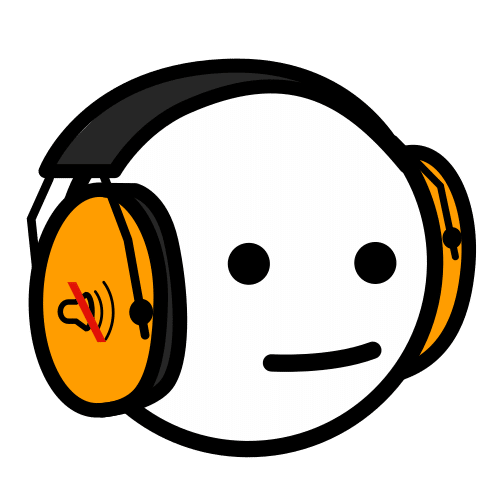

'want' — same gold=5441


id,ARASAAC,df_hf
5441,,

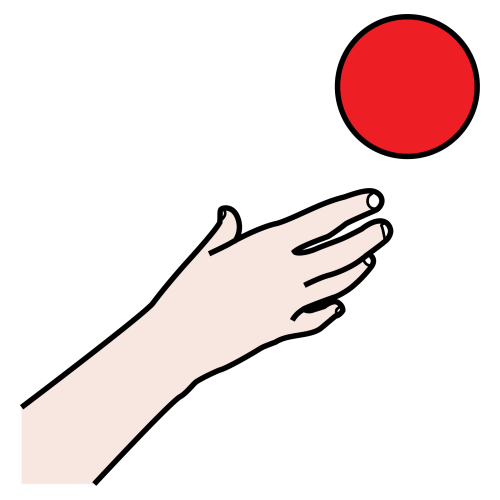

'wear' — DIVERGES


id,ARASAAC,df_hf
11208,,
6627,,

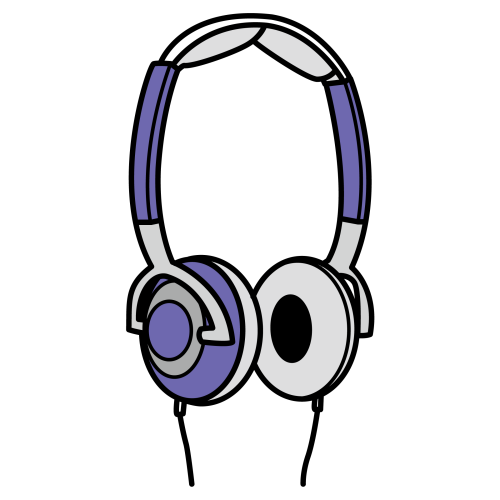
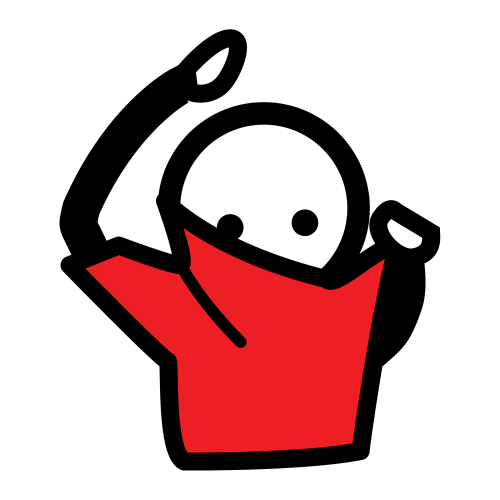

'my noise-canceling headphones' — DIVERGES


id,ARASAAC,df_hf
11208,,
37486,,

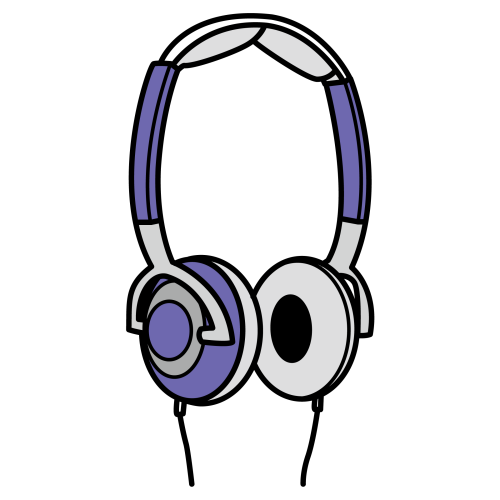
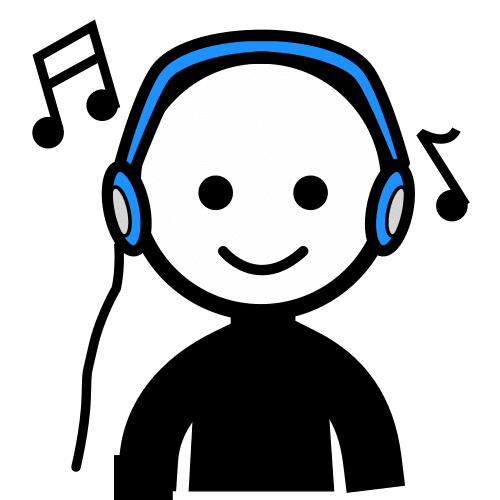

In [21]:
group_idx = 1  # cambia questo per navigare tra i gruppi

sent, rows = ambiguous_groups[group_idx]
print(f"[{group_idx+1}/{len(ambiguous_groups)}] \"{sent}\"\n")

for concept_idx in range(len(rows[0]["concepts"])):
    text  = rows[0]["concepts"][concept_idx]["concept_text"]
    golds = [r["concepts"][concept_idx]["gold_id"] for r in rows]
    if len(set(golds)) == 1:
        print(f"'{text}' — same gold={golds[0]}")
        show_pictograms(golds[0])
    else:
        print(f"'{text}' — DIVERGES")
        show_pictograms(list(set(golds)))

After observing them i have to say that some are meaningless, some seems non exact and others are reasonable. Anyway they are not that much and we cannot remove them based on precived quality, since we cannot look at the whole datasets so we can keep them.

In [22]:
# NOTE: this may be a problem and it wasn't checked before

repeated_gold_in_sentence = [
    (row["sentence"], [c["gold_id"] for c in row["concepts"]])
    for _, row in df_eval_filtered.iterrows()
    if len(set(c["gold_id"] for c in row["concepts"])) < len(row["concepts"])
]

print(f"Sentences with repeated gold id within same row: {len(repeated_gold_in_sentence)}")

Sentences with repeated gold id within same row: 0


At this point, looking at the dataset itself we can remove only the exact duplicates.

In [23]:
# keep first occurrence of exact duplicates, keep all unique signatures for ambiguous
seen_sigs, keep_idx = set(), []
for idx, row in df_eval_filtered.iterrows():
    sig = row_sig(row)
    if sig not in seen_sigs:
        seen_sigs.add(sig)
        keep_idx.append(idx)

df_eval_filtered_no_dup = df_eval_filtered.loc[keep_idx].reset_index(drop=True)
print(f"df_eval_filtered before exact duplicate removal: {len(df_eval_filtered)}")
print(f"df_eval_filtered after exact duplicate removal: {len(df_eval_filtered_no_dup)}")

df_eval_filtered before exact duplicate removal: 1787
df_eval_filtered after exact duplicate removal: 1760


## 4. Overlaps and differences

In [24]:
local_ids  = set(df_local["pictogram_id"])
hf_ids     = set(df_hf["pictogram_id"]) - none_ids
only_local = local_ids - hf_ids
only_hf    = hf_ids - local_ids
both       = local_ids & hf_ids

print(f"df_local ids          : {len(local_ids)}")
print(f"df_hf ids (valid)     : {len(hf_ids)}")
print(f"\nOnly in df_local      : {len(only_local)} ({len(only_local)/len(local_ids):.1%} of local)")
print(f"Only in df_hf         : {len(only_hf)} ({len(only_hf)/len(hf_ids):.1%} of hf)")
print(f"In both               : {len(both)} ({len(both)/len(local_ids | hf_ids):.1%} of union)")

df_local ids          : 13780
df_hf ids (valid)     : 10657

Only in df_local      : 3147 (22.8% of local)
Only in df_hf         : 24 (0.2% of hf)
In both               : 10633 (77.0% of union)


In [25]:
eval_gold_ids = set(
    c["gold_id"]
    for _, row in df_eval_filtered_no_dup.iterrows()
    for c in row["concepts"]
)
eval_all_ids = eval_gold_ids | set(
    cid
    for _, row in df_eval_filtered_no_dup.iterrows()
    for c in row["concepts"]
    for cid in c["candidate_ids"]
)

for label, id_set in [("gold ids", eval_gold_ids), ("all ids (gold+cands)", eval_all_ids)]:
    print(f"\nEval {label}: {len(id_set)}")
    print(f"\t- in both sources  : {len(id_set & both)}")
    print(f"\t- only in local    : {len(id_set & only_local)}")
    print(f"\t- only in hf       : {len(id_set & only_hf)}")
    print(f"\t- nowhere          : {len(id_set - local_ids - hf_ids)}")


Eval gold ids: 1026
	- in both sources  : 1023
	- only in local    : 0
	- only in hf       : 3
	- nowhere          : 0

Eval all ids (gold+cands): 2504
	- in both sources  : 2286
	- only in local    : 0
	- only in hf       : 4
	- nowhere          : 214


In order to merge correctly `df_local` and `df_hf` we have to check that the overlap between them (which is most of the data) is semantically equivalent, meaning that the same id has the same metadata (or similar).

**NOTE**: the 214 unreachable ids are the ones without meatadata that we maintained in the candidates since they were less than 20% of each candidates. 

In [26]:
W_KW, W_CAT, W_TAG = 0.6, 0.2, 0.2

def jaccard(a: set, b: set) -> float:
    if not a and not b: return 1.0  # both empty = identical
    if not a or  not b: return 0.0  # one missing = no overlap
    return len(a & b) / len(a | b)

def get_kw_set(kws):
    if kws is None: return set()
    if isinstance(kws, np.ndarray): kws = kws.tolist()
    if not isinstance(kws, list): return set()
    return {e["keyword"].lower().strip() for e in kws if isinstance(e, dict) and "keyword" in e}

def get_list_set(lst):
    if lst is None: return set()
    if not isinstance(lst, (list, np.ndarray)): return set()
    return {str(x).lower().strip() for x in lst if x}

def metadata_similarity(pid, loc_by_pid, hf_by_pid):
    in_local = pid in loc_by_pid.index
    in_hf    = pid in hf_by_pid.index

    if not in_local or not in_hf:
        # only in one source — score is None, handled separately
        return {"pid": pid, "in_local": in_local, "in_hf": in_hf,
                "kw_jaccard": None, "cat_jaccard": None, "tag_jaccard": None, "score": None}

    row_loc = loc_by_pid.loc[pid]
    row_hf  = hf_by_pid.loc[pid]

    kw_j  = jaccard(get_kw_set(row_loc["keywords"]),   get_kw_set(row_hf["keywords"]))
    cat_j = jaccard(get_list_set(row_loc["categories"]), get_list_set(row_hf["categories"]))
    tag_j = jaccard(get_list_set(row_loc["tags"]),       get_list_set(row_hf["tags"]))

    score = W_KW * kw_j + W_CAT * cat_j + W_TAG * tag_j

    return {"pid": pid, "in_local": in_local, "in_hf": in_hf,
            "kw_jaccard": kw_j, "cat_jaccard": cat_j, "tag_jaccard": tag_j, "score": score}

loc_by_pid = df_local.set_index("pictogram_id")
hf_by_pid  = df_hf[df_hf["pictogram_id"].isin(hf_ids)].set_index("pictogram_id")

all_ids = local_ids | hf_ids
records = [metadata_similarity(pid, loc_by_pid, hf_by_pid) for pid in all_ids]
df_sim  = pd.DataFrame(records)

# summary
overlap_sim = df_sim[df_sim["score"].notna()]
print(f"IDs in both (scored)   : {len(overlap_sim)}")
print(f"IDs only in local      : {df_sim['in_hf'].eq(False).sum()}")
print(f"IDs only in hf         : {df_sim['in_local'].eq(False).sum()}")
print(f"\nScore distribution (keywords*0.6 + categories*0.2 + tags*0.2):")
print(overlap_sim["score"].describe().round(3))
print(f"\n\t- score == 1.0 (identical) : {(overlap_sim['score'] == 1.0).sum()}")
print(f"\t- score >= 0.8             : {(overlap_sim['score'] >= 0.8).sum()}")
print(f"\t- score >= 0.5             : {(overlap_sim['score'] >= 0.5).sum()}")
print(f"\t- score <  0.5             : {(overlap_sim['score'] <  0.5).sum()}")
print(f"\t- score == 0.0             : {(overlap_sim['score'] == 0.0).sum()}")

IDs in both (scored)   : 10633
IDs only in local      : 3147
IDs only in hf         : 24

Score distribution (keywords*0.6 + categories*0.2 + tags*0.2):
count    10633.000
mean         0.985
std          0.064
min          0.214
25%          1.000
50%          1.000
75%          1.000
max          1.000
Name: score, dtype: float64

	- score == 1.0 (identical) : 9798
	- score >= 0.8             : 10368
	- score >= 0.5             : 10582
	- score <  0.5             : 51
	- score == 0.0             : 0


In [27]:
low_sim = df_sim[df_sim["score"].notna() & (df_sim["score"] < 0.5)].sort_values("score")
sample = low_sim.sample(min(10, len(low_sim)), random_state=42)

for _, row in sample.iterrows():
    pid = row["pid"]
    print(f"pid={pid}  score={row['score']:.3f}  "
          f"kw={row['kw_jaccard']:.3f}  cat={row['cat_jaccard']:.3f}  tag={row['tag_jaccard']:.3f}")
    print(f"\tkeywords:")
    print(f"\t\tlocal : {get_kw_set(loc_by_pid.loc[pid]['keywords'])}")
    print(f"\t\thf    : {get_kw_set(hf_by_pid.loc[pid]['keywords'])}")
    print(f"\tcategories:")
    print(f"\t\tlocal : {get_list_set(loc_by_pid.loc[pid]['categories'])}")
    print(f"\t\thf    : {get_list_set(hf_by_pid.loc[pid]['categories'])}")
    print(f"\ttags:")
    print(f"\t\tlocal : {get_list_set(loc_by_pid.loc[pid]['tags'])}")
    print(f"\t\thf    : {get_list_set(hf_by_pid.loc[pid]['tags'])}")
    print()

pid=36632  score=0.400  kw=0.000  cat=1.000  tag=1.000
	keywords:
		local : {'cut a steak', 'cut food'}
		hf    : {'cut', 'chop'}
	categories:
		local : {'animal-based food', 'routine', 'verb'}
		hf    : {'animal-based food', 'routine', 'verb'}
	tags:
		local : {'verb', 'food', 'animal-based food', 'feeding', 'communication', 'language', 'person', 'routine'}
		hf    : {'verb', 'food', 'animal-based food', 'feeding', 'communication', 'language', 'person', 'routine'}

pid=30960  score=0.400  kw=0.000  cat=1.000  tag=1.000
	keywords:
		local : {'drain the dishes'}
		hf    : {'drain'}
	categories:
		local : {'crockery', 'verb'}
		hf    : {'crockery', 'verb'}
	tags:
		local : {'verb', 'communication', 'language', 'household', 'home', 'crockery', 'object'}
		hf    : {'verb', 'communication', 'language', 'household', 'home', 'crockery', 'object'}

pid=27717  score=0.400  kw=0.000  cat=1.000  tag=1.000
	keywords:
		local : {'deposit the keys', 'put the keys', 'leave the keys'}
		hf    : {'put'

Ok then thy are clearly overlapping as meanings (looking at metadata). We should also ensure that the others are coherent but there are only 24 on the `df_hf` side so it should not be a problem.

## 5. Merge source dataset and download datasets

The merge strategy is to take `df_local` as the base and add the 24 IDs that are only in `df_hf`, since the local dataset is richer (has synsets, type, plural) and the overlap is semantically equivalent.

In [28]:
def normalize_hf_keywords(kws):
    if isinstance(kws, np.ndarray): kws = kws.tolist()
    if not isinstance(kws, list): return []
    return [
        {
            "type"    : None,     # unknown in hf schema
            "keyword" : e.get("keyword", ""),
            "plural"  : None,     # not available in hf
            "meaning" : e.get("meaning", None),
        }
        for e in kws if isinstance(e, dict)
    ]

def normalize_hf_row(row):
    return {
        "pictogram_id" : row["pictogram_id"],
        "keywords"     : normalize_hf_keywords(row["keywords"]),
        "categories"   : list(row["categories"]) if isinstance(row["categories"], np.ndarray) else (row["categories"] or []),
        "synsets"      : [],      # not available in hf
        "tags"         : list(row["tags"]) if isinstance(row["tags"], np.ndarray) else (row["tags"] or []),
        "sex"          : None,
        "violence"     : None,
        "schematic"    : None,
        "aac"          : None,
        "aac_color"    : None,
        "skin"         : None,
        "hair"         : None,
        "created"      : None,
        "last_updated" : None,
    }

df_hf_only_normalized = pd.DataFrame([
    normalize_hf_row(row)
    for _, row in df_hf[df_hf["pictogram_id"].isin(only_hf)].iterrows()
])

df_merged = pd.concat([df_local, df_hf_only_normalized], ignore_index=True).sort_values("pictogram_id").reset_index(drop=True)

assert len(df_merged) == len(local_ids) + len(only_hf)
assert list(df_merged.columns) == list(df_local.columns)
print(f"df_local   : {len(df_local)}")
print(f"df_hf only : {len(df_hf_only_normalized)}")
print(f"df_merged  : {len(df_merged)}")

df_local   : 13780
df_hf only : 24
df_merged  : 13804


In order to write the new dataset as it was the official from ARASAAC, we have to build also the other structures and write them as .json files.

In [29]:
import json
from datetime import datetime, timezone
from pathlib import Path

def _now_iso():
    return datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

def _write_json(path, data, label):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    tmp.replace(path)
    print(f"wrote {label} -> {path.name}")

EN_EVAL_DIR.mkdir(parents=True, exist_ok=True)
run_ts = _now_iso()
meta   = {}

# pictograms.json { id_str -> record }
pictograms = {}
for _, row in df_merged.iterrows():
    pid = int(row["pictogram_id"])
    pictograms[str(pid)] = {
        "id"          : pid,
        "keywords"    : row["keywords"]   if isinstance(row["keywords"],   list) else [],
        "categories"  : row["categories"] if isinstance(row["categories"], list) else [],
        "synsets"     : row["synsets"]    if isinstance(row["synsets"],    list) else [],
        "tags"        : row["tags"]       if isinstance(row["tags"],       list) else [],
        "sex"         : row["sex"],
        "violence"    : row["violence"],
        "schematic"   : row["schematic"],
        "aac"         : row["aac"],
        "aac_color"   : row["aac_color"],
        "skin"        : row["skin"],
        "hair"        : row["hair"],
        "created"     : row["created"],
        "last_updated": row["last_updated"],
    }
_write_json(EN_EVAL_DIR / "pictograms.json", pictograms, f"pictograms {len(pictograms)} records")
meta["pictograms"] = {"built_at": run_ts, "count": len(pictograms)}

# keywords.json, sorted list of unique keyword strings
keyword_set = {
    kw["keyword"]
    for rec in pictograms.values()
    for kw in rec["keywords"]
    if isinstance(kw, dict) and kw.get("keyword")
}
keywords = sorted(keyword_set)
_write_json(EN_EVAL_DIR / "keywords.json", keywords, f"keywords {len(keywords)} entries")
meta["keywords"] = {"built_at": run_ts, "count": len(keywords)}

# keyword_index.json { keyword -> [id_str, ...] }
keyword_index = {}
for pid_str, rec in pictograms.items():
    for kw in rec["keywords"]:
        term = kw.get("keyword") if isinstance(kw, dict) else None
        if term:
            keyword_index.setdefault(term, [])
            if pid_str not in keyword_index[term]:
                keyword_index[term].append(pid_str)
keyword_index = {k: sorted(v) for k, v in sorted(keyword_index.items())}
_write_json(EN_EVAL_DIR / "keyword_index.json", keyword_index, f"keyword_index {len(keyword_index)} entries")
meta["keyword_index"] = {"built_at": run_ts, "count": len(keyword_index)}

# synset_index.json { synset_id -> [id_str, ...] }
synset_index = {}
for pid_str, rec in pictograms.items():
    for syn in rec["synsets"]:
        synset_index.setdefault(syn, [])
        if pid_str not in synset_index[syn]:
            synset_index[syn].append(pid_str)
synset_index = {k: sorted(v) for k, v in sorted(synset_index.items())}
_write_json(EN_EVAL_DIR / "synset_index.json", synset_index, f"synset_index {len(synset_index)} synsets")
meta["synset_index"] = {"built_at": run_ts, "count": len(synset_index)}

# _meta.json
_write_json(EN_EVAL_DIR / "_meta.json", meta, "_meta")

wrote pictograms 13804 records -> pictograms.json
wrote keywords 15761 entries -> keywords.json
wrote keyword_index 15761 entries -> keyword_index.json
wrote synset_index 8422 synsets -> synset_index.json
wrote _meta -> _meta.json


In [30]:
df_eval_filtered_no_dup.to_parquet(EVAL_FILTERED, index=False)
print(f"wrote eval_filtered -> {EVAL_FILTERED.name}  ({len(df_eval_filtered_no_dup)} rows)")

wrote eval_filtered -> eval_filtered.parquet  (1760 rows)
